PRAKTIKUM 7.1: TRANSFORMASI FOURIER DAN ANALISIS SPEKTRUM


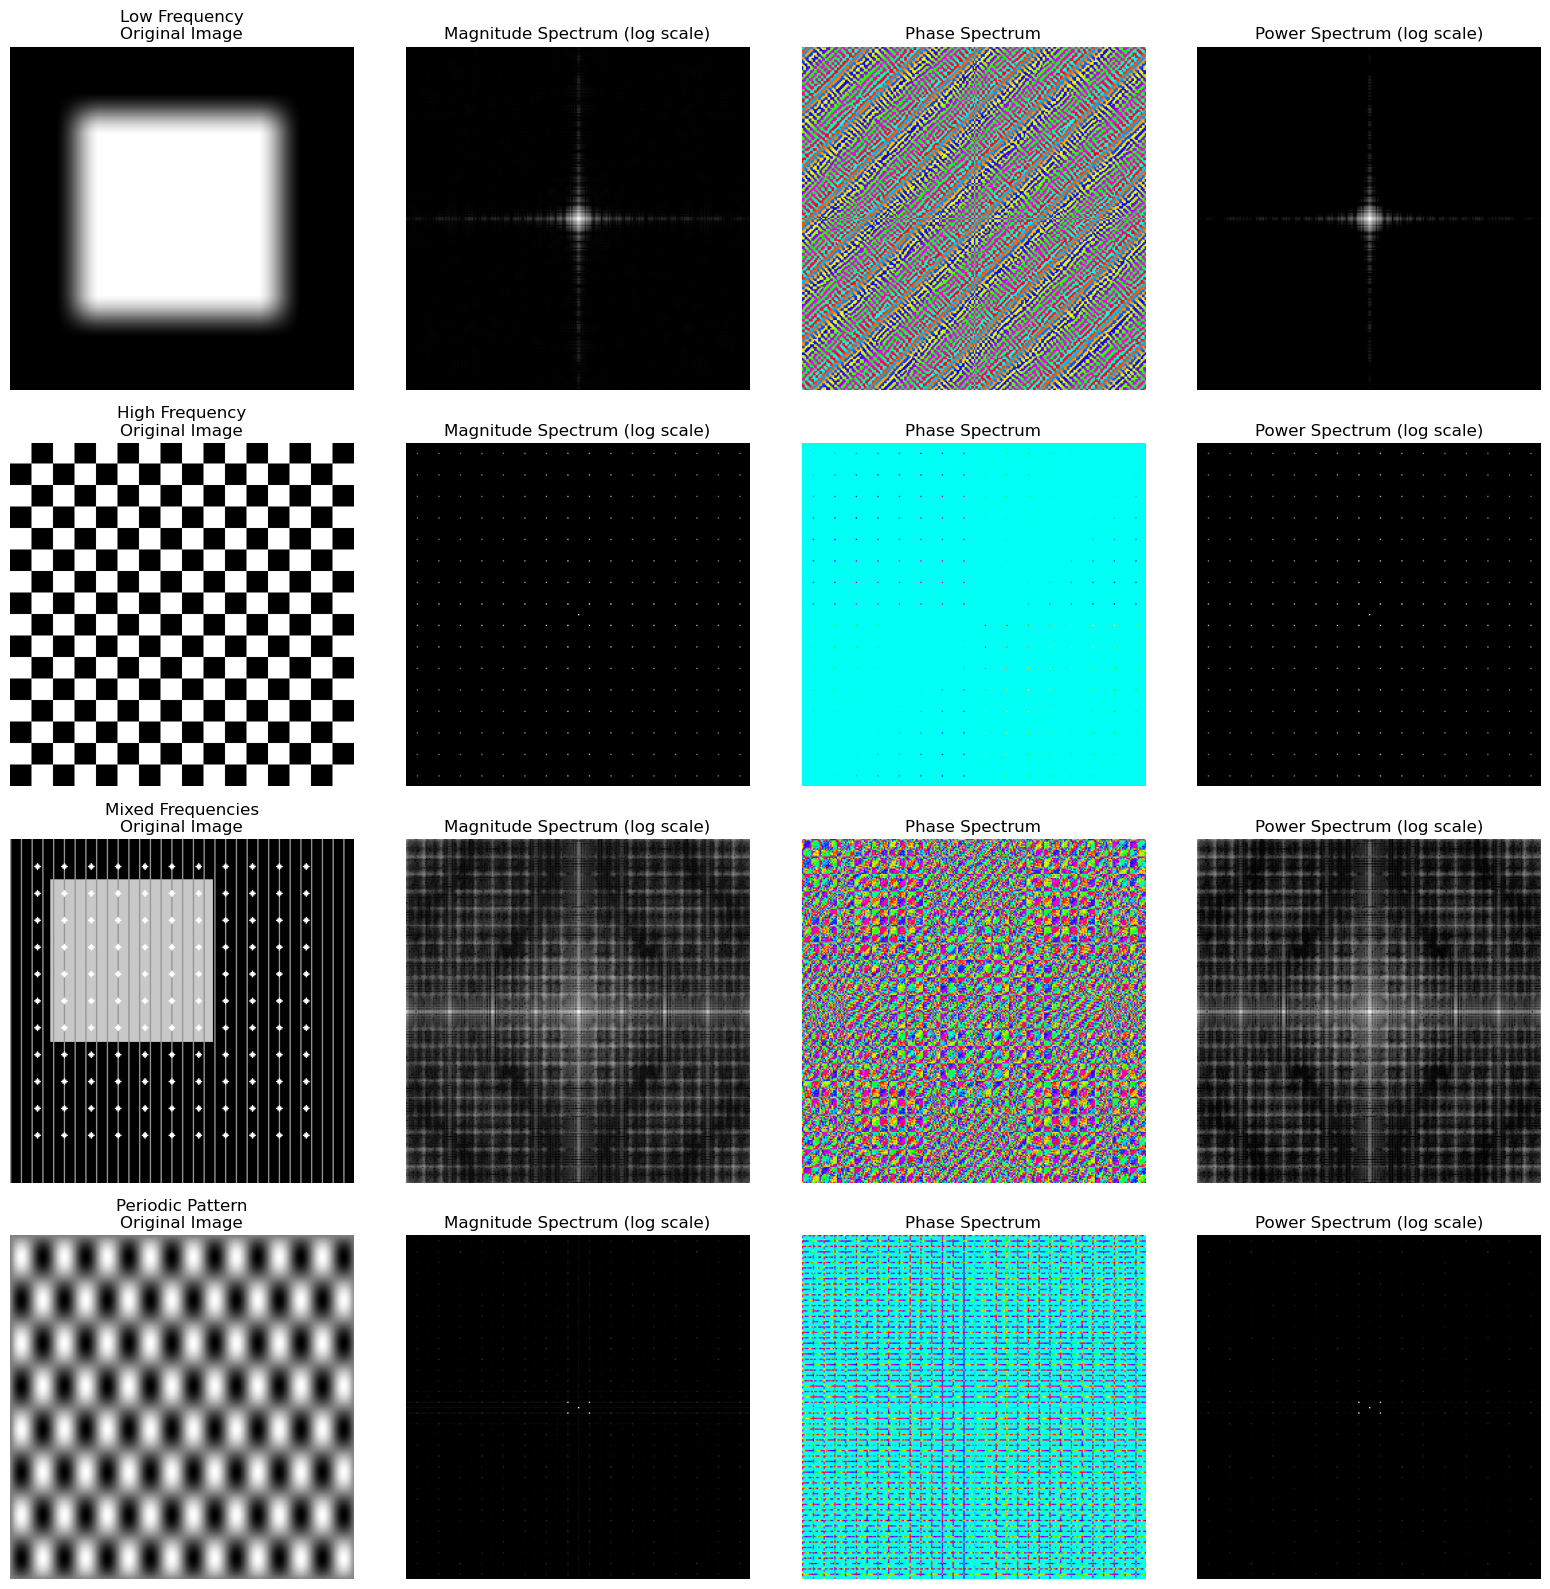


DEMONSTRASI: IMPORTANCE OF PHASE INFORMATION
--------------------------------------------------

Swapping Experiment:
1. Magnitude dari Image1 + Phase dari Image2
2. Magnitude dari Image2 + Phase dari Image1


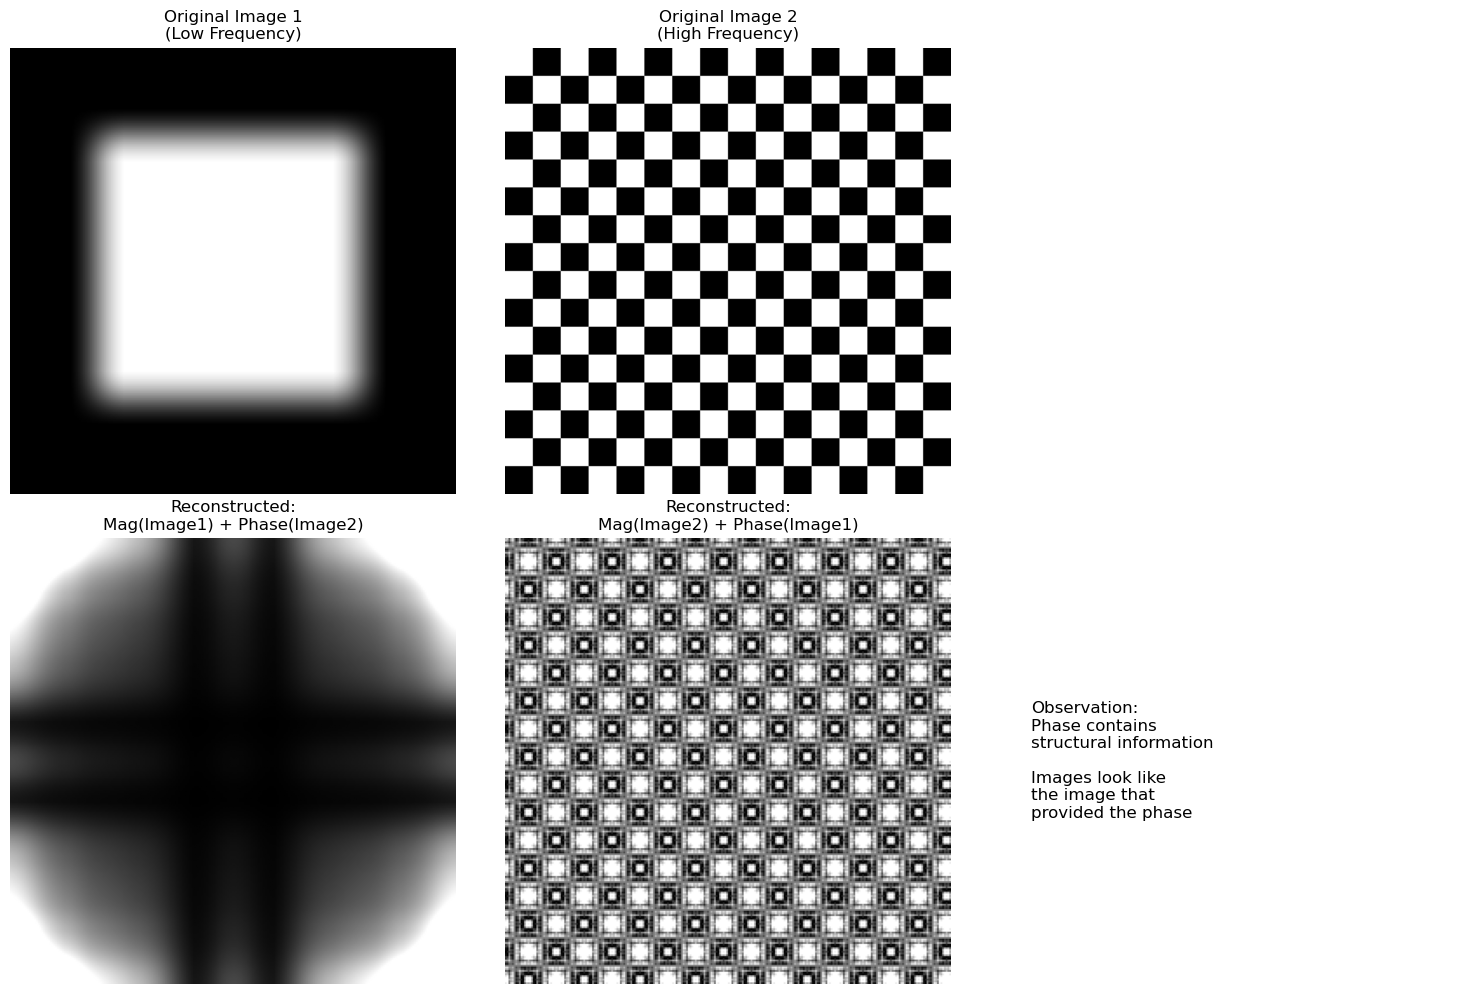


ANALISIS DISTRIBUSI FREKUENSI
----------------------------------------


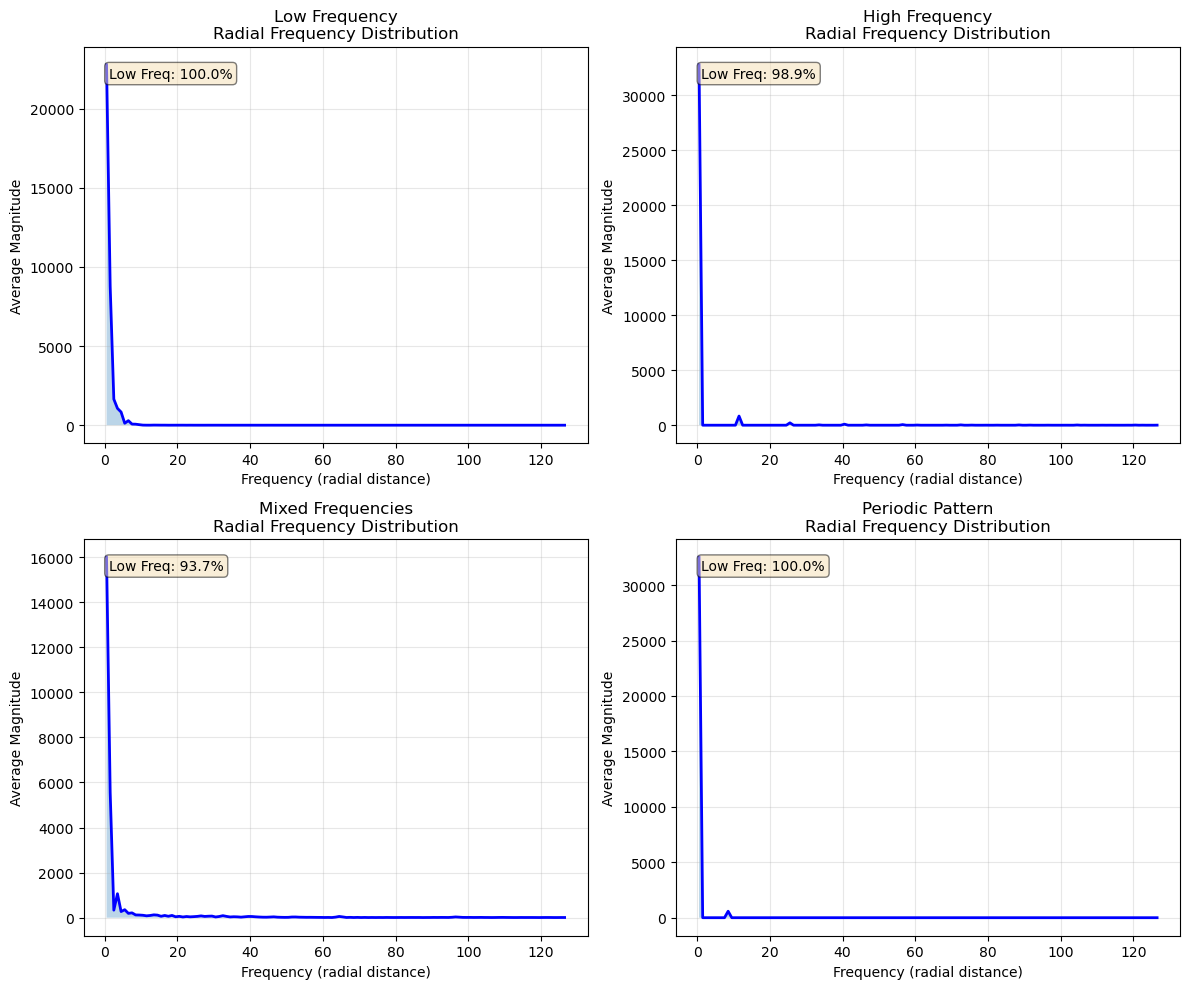


FREQUENCY DOMAIN STATISTICS
--------------------------------------------------
Image Type           DC Component    Avg Magnitude   Energy         
--------------------------------------------------
Low Frequency        22765.35        2.620592        1324207360.00  
High Frequency       32768.00        3.720386        2147483648.00  
Mixed Frequencies    15993.20        17.258163       784453504.00   
Periodic Pattern     32512.89        0.550557        1323544960.00  


In [1]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from scipy.fft import fft2, fftshift, ifft2, ifftshift

def praktikum_7_1():
    """
    Transformasi Fourier dan analisis spektrum frekuensi
    """
    print("PRAKTIKUM 7.1: TRANSFORMASI FOURIER DAN ANALISIS SPEKTRUM")
    print("=" * 60)
    
    # Fungsi untuk membuat citra dengan karakteristik frekuensi berbeda
    def create_frequency_test_images():
        images = {}
        
        # 1. Image dengan dominan low frequency (blurred rectangle)
        img_low = np.zeros((256, 256), dtype=np.float32)
        cv2.rectangle(img_low, (50, 50), (200, 200), 1.0, -1)
        img_low = cv2.GaussianBlur(img_low, (31, 31), 10)
        images['Low Frequency'] = (img_low * 255).astype(np.uint8)
        
        # 2. Image dengan dominan high frequency (checkerboard pattern)
        img_high = np.zeros((256, 256), dtype=np.uint8)
        for i in range(0, 256, 16):
            for j in range(0, 256, 16):
                if (i//16 + j//16) % 2 == 0:
                    img_high[i:i+16, j:j+16] = 255
        images['High Frequency'] = img_high
        
        # 3. Image dengan mixed frequencies (gabungan pattern)
        img_mixed = np.zeros((256, 256), dtype=np.uint8)
        # Low frequency component
        cv2.rectangle(img_mixed, (30, 30), (150, 150), 200, -1)
        # Medium frequency component (stripes)
        for i in range(0, 256, 8):
            cv2.line(img_mixed, (i, 0), (i, 255), 150, 1)
        # High frequency component (dots)
        for i in range(20, 236, 20):
            for j in range(20, 236, 20):
                cv2.circle(img_mixed, (i, j), 2, 255, -1)
        images['Mixed Frequencies'] = img_mixed
        
        # 4. Image dengan periodic pattern (sinusoidal)
        x = np.arange(256)
        y = np.arange(256)
        X, Y = np.meshgrid(x, y)
        img_periodic = 127 + 127 * np.sin(2*np.pi*X/32) * np.sin(2*np.pi*Y/64)
        images['Periodic Pattern'] = img_periodic.astype(np.uint8)
        
        return images
    
    # Fungsi untuk analisis Fourier
    def analyze_fourier_spectrum(image):
        """Analisis lengkap spektrum Fourier"""
        # Convert to float untuk processing
        img_float = image.astype(np.float32) / 255.0
        
        # Compute FFT
        f = fft2(img_float)
        fshift = fftshift(f)
        
        # Compute magnitude spectrum (log scale untuk display)
        magnitude_spectrum = np.abs(fshift)
        log_magnitude = np.log(1 + magnitude_spectrum)
        
        # Compute phase spectrum
        phase_spectrum = np.angle(fshift)
        
        # Compute power spectrum
        power_spectrum = np.abs(fshift) ** 2
        log_power = np.log(1 + power_spectrum)
        
        return {
            'magnitude': magnitude_spectrum,
            'log_magnitude': log_magnitude,
            'phase': phase_spectrum,
            'power': power_spectrum,
            'log_power': log_power,
            'fft': f,
            'fft_shifted': fshift
        }
    
    # Fungsi untuk reconstruct citra dari magnitude/phase saja
    def reconstruct_from_components(magnitude, phase):
        """Reconstruct image from magnitude and phase components"""
        # Combine magnitude and phase
        complex_spectrum = magnitude * np.exp(1j * phase)
        
        # Inverse shift and FFT
        f_ishift = ifftshift(complex_spectrum)
        img_reconstructed = np.abs(ifft2(f_ishift))
        
        return np.clip(img_reconstructed * 255, 0, 255).astype(np.uint8)
    
    # Buat citra test
    test_images = create_frequency_test_images()
    
    # Analisis setiap citra
    fig, axes = plt.subplots(len(test_images), 4, figsize=(16, 4*len(test_images)))
    
    for idx, (title, image) in enumerate(test_images.items()):
        # Analisis Fourier
        analysis = analyze_fourier_spectrum(image)
        
        # Plot 1: Original image
        axes[idx, 0].imshow(image, cmap='gray')
        axes[idx, 0].set_title(f'{title}\nOriginal Image')
        axes[idx, 0].axis('off')
        
        # Plot 2: Magnitude spectrum (log scale)
        im_mag = axes[idx, 1].imshow(analysis['log_magnitude'], cmap='gray')
        axes[idx, 1].set_title('Magnitude Spectrum (log scale)')
        axes[idx, 1].axis('off')
        
        # Plot 3: Phase spectrum
        im_phase = axes[idx, 2].imshow(analysis['phase'], cmap='hsv')
        axes[idx, 2].set_title('Phase Spectrum')
        axes[idx, 2].axis('off')
        
        # Plot 4: Power spectrum (log scale)
        im_power = axes[idx, 3].imshow(analysis['log_power'], cmap='gray')
        axes[idx, 3].set_title('Power Spectrum (log scale)')
        axes[idx, 3].axis('off')
    
    plt.tight_layout()
    plt.show()
    
    # Demonstrasi importance of phase
    print("\nDEMONSTRASI: IMPORTANCE OF PHASE INFORMATION")
    print("-" * 50)
    
    # Ambil dua citra berbeda
    img1 = test_images['Low Frequency']
    img2 = test_images['High Frequency']
    
    # Analisis Fourier masing-masing
    analysis1 = analyze_fourier_spectrum(img1)
    analysis2 = analyze_fourier_spectrum(img2)
    
    # Lakukan swapping experiment
    print("\nSwapping Experiment:")
    print("1. Magnitude dari Image1 + Phase dari Image2")
    print("2. Magnitude dari Image2 + Phase dari Image1")
    
    # Reconstruct dengan swapped components
    reconstructed_1mag_2phase = reconstruct_from_components(
        analysis1['magnitude'], analysis2['phase']
    )
    
    reconstructed_2mag_1phase = reconstruct_from_components(
        analysis2['magnitude'], analysis1['phase']
    )
    
    # Visualisasi hasil swapping
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    
    # Row 1: Original images
    axes[0, 0].imshow(img1, cmap='gray')
    axes[0, 0].set_title('Original Image 1\n(Low Frequency)')
    axes[0, 0].axis('off')
    
    axes[0, 1].imshow(img2, cmap='gray')
    axes[0, 1].set_title('Original Image 2\n(High Frequency)')
    axes[0, 1].axis('off')
    
    axes[0, 2].axis('off')  # Empty for alignment
    
    # Row 2: Reconstructed images
    axes[1, 0].imshow(reconstructed_1mag_2phase, cmap='gray')
    axes[1, 0].set_title('Reconstructed:\nMag(Image1) + Phase(Image2)')
    axes[1, 0].axis('off')
    
    axes[1, 1].imshow(reconstructed_2mag_1phase, cmap='gray')
    axes[1, 1].set_title('Reconstructed:\nMag(Image2) + Phase(Image1)')
    axes[1, 1].axis('off')
    
    # Keterangan
    axes[1, 2].text(0.1, 0.5, 
                   'Observation:\nPhase contains\nstructural information\n\n'
                   'Images look like\nthe image that\nprovided the phase',
                   transform=axes[1, 2].transAxes,
                   fontsize=12, verticalalignment='center')
    axes[1, 2].axis('off')
    
    plt.tight_layout()
    plt.show()
    
    # Analisis distribusi frekuensi
    print("\nANALISIS DISTRIBUSI FREKUENSI")
    print("-" * 40)
    
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    
    for idx, (title, image) in enumerate(list(test_images.items())[:4]):
        analysis = analyze_fourier_spectrum(image)
        
        # Hitung radial profile
        rows, cols = image.shape
        crow, ccol = rows // 2, cols // 2
        
        # Buat grid radial
        y, x = np.ogrid[-crow:rows-crow, -ccol:cols-ccol]
        r = np.sqrt(x*x + y*y)
        
        # Bin radii
        r_bins = np.arange(0, max(rows, cols)//2, 1)
        r_centers = (r_bins[:-1] + r_bins[1:]) / 2
        
        # Compute radial profile dari magnitude spectrum
        magnitude = analysis['magnitude']
        radial_profile = []
        
        for i in range(len(r_bins)-1):
            mask = (r >= r_bins[i]) & (r < r_bins[i+1])
            if np.any(mask):
                radial_profile.append(np.mean(magnitude[mask]))
            else:
                radial_profile.append(0)
        
        # Plot radial profile
        row = idx // 2
        col = idx % 2
        
        axes[row, col].plot(r_centers, radial_profile, 'b-', linewidth=2)
        axes[row, col].fill_between(r_centers, 0, radial_profile, alpha=0.3)
        axes[row, col].set_title(f'{title}\nRadial Frequency Distribution')
        axes[row, col].set_xlabel('Frequency (radial distance)')
        axes[row, col].set_ylabel('Average Magnitude')
        axes[row, col].grid(True, alpha=0.3)
        
        # Tentukan apakah dominan low atau high frequency
        total_energy = np.sum(radial_profile)
        low_freq_energy = np.sum(radial_profile[:len(radial_profile)//4])
        low_freq_percentage = (low_freq_energy / total_energy) * 100
        
        axes[row, col].text(0.05, 0.95, f'Low Freq: {low_freq_percentage:.1f}%',
                           transform=axes[row, col].transAxes,
                           fontsize=10, verticalalignment='top',
                           bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    plt.tight_layout()
    plt.show()
    
    # Frequency domain statistics
    print("\nFREQUENCY DOMAIN STATISTICS")
    print("-" * 50)
    print(f"{'Image Type':<20} {'DC Component':<15} {'Avg Magnitude':<15} {'Energy':<15}")
    print("-" * 50)
    
    for title, image in test_images.items():
        analysis = analyze_fourier_spectrum(image)
        
        # DC component (zero frequency)
        dc_component = analysis['magnitude'][128, 128]  # Center setelah fftshift
        
        # Average magnitude (excluding DC)
        magnitude_no_dc = analysis['magnitude'].copy()
        magnitude_no_dc[128, 128] = 0
        avg_magnitude = np.mean(magnitude_no_dc)
        
        # Total energy
        total_energy = np.sum(analysis['power'])
        
        print(f"{title:<20} {dc_component:<15.2f} {avg_magnitude:<15.6f} {total_energy:<15.2f}")
    
    return test_images

test_images = praktikum_7_1()